In [2]:
import numpy as np
import pandas as pd

In [3]:
from sklearn.datasets import load_diabetes

In [5]:
dia=load_diabetes()

In [6]:
print(dia.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [7]:
X=dia.data
y=dia.target

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
X_train

array([[ 0.07076875,  0.05068012,  0.01211685, ...,  0.03430886,
         0.02736405, -0.0010777 ],
       [-0.00914709,  0.05068012, -0.01806189, ...,  0.07120998,
         0.00027248,  0.01963284],
       [ 0.00538306, -0.04464164,  0.04984027, ..., -0.00259226,
         0.01703607, -0.01350402],
       ...,
       [ 0.03081083, -0.04464164, -0.02021751, ..., -0.03949338,
        -0.01090325, -0.0010777 ],
       [-0.01277963, -0.04464164, -0.02345095, ..., -0.00259226,
        -0.03845972, -0.03835666],
       [-0.09269548, -0.04464164,  0.02828403, ..., -0.03949338,
        -0.00514219, -0.0010777 ]])

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr=LinearRegression()

In [15]:
lr.fit(X_train,y_train)

LinearRegression()

In [17]:
y_pred=lr.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error

In [19]:
print("MAE : ",mean_absolute_error(y_pred,y_test))
print("RMSE  : ",root_mean_squared_error(y_pred,y_test))
print("r2 score : ",r2_score(y_pred,y_test))

MAE :  42.794094679599944
RMSE  :  53.85344583676593
r2 score :  0.006904915832163905


# Ridge Regularization

In [20]:
from sklearn.linear_model import Ridge

In [33]:
r=Ridge(alpha=0.001)  # alpha means lambda

In [34]:
r.fit(X_train,y_train)

Ridge(alpha=10)

In [35]:
y_pre=r.predict(X_test)

In [36]:
print("MAE : ",mean_absolute_error(y_pre,y_test))
print("RMSE  : ",root_mean_squared_error(y_pre,y_test))
print("r2 score : ",r2_score(y_pre,y_test))

MAE :  58.03075641003829
RMSE  :  66.66297800625937
r2 score :  -37.452895896956235


# Generate data and Show Underfitting,Overfitting

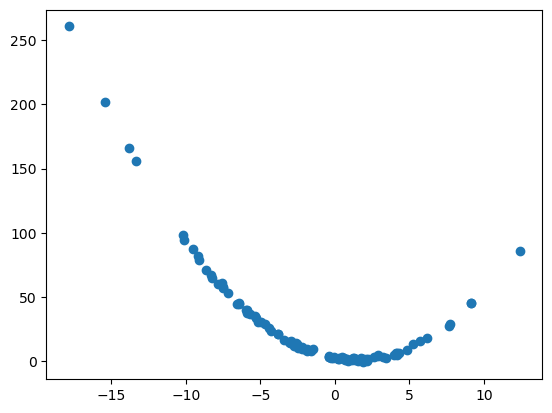

In [27]:
m=100
x1=5*np.random.randn(m,1)-2
x2=0.7 * x1 **2-2*x1+3+np.random.randn(m,1)
import matplotlib.pyplot as plt
plt.scatter(x1,x2)
plt.show()

C:\Users\91886\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.17195e-39): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\91886\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=7.8529e-39): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


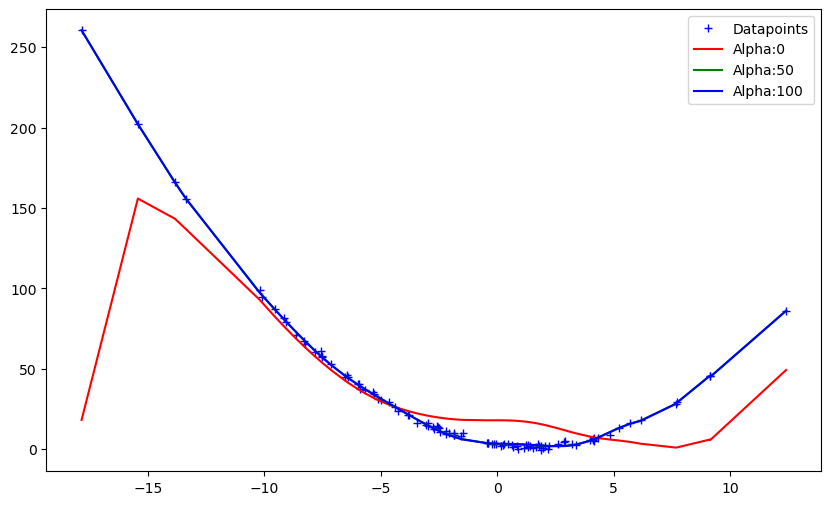

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_pred_ridge(x1,x2,alpha):
    model=Pipeline([
        ('ploy_feat',PolynomialFeatures(degree=16)),
        ('ridge',Ridge(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)
alphas=[0,50,100]
cs=['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label='Datapoints')

for alpha, c in zip(alphas,cs):
    preds=get_pred_ridge(x1,x2,alpha)
    #plot 
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])],c,label='Alpha:{}'.format(alpha))

plt.legend()
plt.show()